# MSE802 Quantum Computing: Assessment 2

## Task 4: Machine Learning Quantum Analysis

The objective of this task is to analyse the provided quantum machine learning code, which trains a parameterised quantum circuit to distinguish two families of binary images, and subsequently to modify it in the ways the brief requires. The analysis concentrates on the circuit component and the formulation of the problem: the data that enter the circuit are identified, together with the portion of the code that serves as the input layer. The training loop is then instrumented so that the objective value and the wall-clock time of every iteration are recorded and plotted, and the execution is moved from the remote Quokka device (Quokka Computing, n.d.) to the local machine by replacing the network call with the Qiskit Aer simulator (Qiskit Contributors, n.d.), so that the dependency on the quantum computer is removed. The disparities in performance between the two execution modes, in terms of both efficiency and effectiveness, are measured and documented; the accompanying Word document presents the detailed report.

The complete source code for this assessment is available on GitHub: https://github.com/eirikrbe/MSE802-PSD/tree/main/MSE802_Assessment2

## Classification with a Parameterised Quantum Circuit

The model analysed here is a variational quantum classifier: a quantum circuit whose rotation angles are free parameters is executed repeatedly, and a classical optimiser adjusts those angles in order to minimise a cost function evaluated from the measurement statistics (Nielsen & Chuang, 2010). Each four-pixel image is written into four qubits by basis encoding, a binary tree of two-qubit blocks then couples the qubits pairwise, and the measurement of a single readout qubit produces the output of the model; the probability of observing 1 on that qubit is the predicted class score (Grant et al., 2018). Training therefore alternates between quantum execution, which evaluates the cost, and classical optimisation, which proposes new angles.

In [1]:
# imports; the core notebook needs no network access
import numpy as np
import scipy as sp
import time
import matplotlib.pyplot as plt

from qiskit import qasm2
from qiskit_aer import AerSimulator

sim = AerSimulator(seed_simulator=802)   # seeded so every run of the notebook reproduces the same counts
np.random.seed(802)                      # seeded data split, initial angles, and SPSA perturbations

## 1. A Single-Qubit Learner

The provided code opens with a minimal example: a single qubit is rotated by an `rx` gate through an angle $\theta$ and measured, and the optimiser searches for the angle at which the measurement always returns 1. Because `rx` maps $|0\rangle$ to a state with $P(1)=\sin^2(\theta/2)$, the expected solution is $\theta=\pm\pi$. In the original notebook every circuit, here and throughout, is sent to the Quokka device as an OpenQASM 2.0 string (Cross et al., 2017); in this notebook the identical string is executed by `run_qasm_local` on the Qiskit Aer simulator instead, which is the local execution modification that Section 4 discusses in detail.

In [2]:
def run_qasm_local(qasm, count=1000):
    """Execute an OpenQASM 2.0 string on the local Aer simulator; return the mean measured bit."""
    counts = sim.run(qasm2.loads(qasm), shots=count).result().get_counts()
    return counts.get('1', 0) / count

def qubit_learner(angle, count=1000):
  qasm = '''
  OPENQASM 2.0;
  include "qelib1.inc";
  qreg q[1];
  creg result[1];
  rx({}) q[0];
  measure q[0] -> result[0];
  '''.format(angle[0])
  return run_qasm_local(qasm, count)   # was: requests.post(req_str_qasm, json=data)

def objective_function(angle, bit=1):
  return np.abs(bit - qubit_learner(angle))**2

In [3]:
sol = sp.optimize.minimize(objective_function,
                           x0=np.random.randn(),
                           method='Nelder-Mead',
                           options={'maxiter': 10})
print(sol)
print(f"\nlearned angle = {sol.x[0]:.3f} rad; P(1) at this angle = {qubit_learner(sol.x):.3f}")

       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.0
             x: [ 3.160e+00]
           nit: 10
          nfev: 25
 final_simplex: (array([[ 3.160e+00],
                       [ 3.158e+00]]), array([ 0.000e+00,  0.000e+00]))

learned angle = 3.160 rad; P(1) at this angle = 1.000


## 2. The Bars and Stripes Data Set

The generator enumerates every binary code of the chosen length and forms an image from each code in two ways: using the code as every row of the image produces columns that are constant, whereas using it as every column produces rows that are constant. The all-black and all-white images, which belong to both families, are discarded; for `length = 2` this leaves four images of four pixels, of which the two column-constant images are labelled 0 (stripes) and the two row-constant images are labelled 1 (bars). Because each pixel is mapped to one qubit, the image size fixes the width of the circuit, and the number of trainable parameters is `2*(length**2 - 1)`, two angles for each of the three entangling blocks. Three of the four images are selected at random for training and the remaining image is held out in order to test generalisation.

In [4]:
def generate_binary_code(bit_length):
    bit_combinations = np.zeros((int(2**bit_length), bit_length))
    for number in range(int(2**bit_length)):
        dividend = number
        bit_index = 0
        while dividend != 0:
            bit_combinations[number, bit_index] = np.remainder(dividend, 2)
            dividend = np.floor_divide(dividend, 2)
            bit_index += 1
    return bit_combinations

def generate_data(length):
    stripes = generate_binary_code(length)
    stripes = np.repeat(stripes, length, 0)
    stripes = stripes.reshape(2 ** length, length * length)

    bars = generate_binary_code(length)
    bars = bars.reshape(2 ** length * length, 1)
    bars = np.repeat(bars, length, 1)
    bars = bars.reshape(2 ** length, length * length)

    return np.vstack((stripes[1:stripes.shape[0]-1],bars[1:bars.shape[0]-1]))

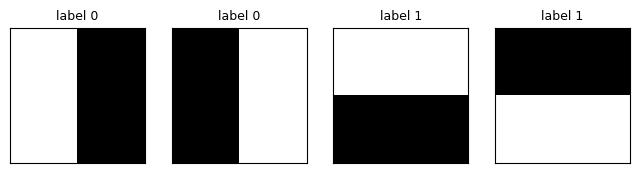

In [5]:
length = 2
dataset = generate_data(length)
labels = np.concatenate((np.zeros(int(2**length-2)), np.ones(int(2**length-2))))
n_parameters = int(2*(length**2-1))

plt.figure(figsize=[8, 2])
for j, img in enumerate(dataset):
    plt.subplot(1, dataset.shape[0], j+1)
    plt.imshow(img.reshape(length, length), cmap="gray")
    plt.title(f"label {int(labels[j])}", fontsize=9)
    plt.xticks([]); plt.yticks([])

In [6]:
# Select 75% of the entries in the array
selected_indices = np.random.choice(dataset.shape[0],
                                    int(dataset.shape[0] * 0.75),
                                    replace=False)

all_indices = np.arange(dataset.shape[0])
unselected_indices = np.setdiff1d(all_indices, selected_indices)

# Get the selected elements
training = dataset[selected_indices]
training_labels = labels[selected_indices]
test = dataset[unselected_indices]
test_labels = labels[unselected_indices]

print("training labels:", training_labels, "| test labels:", test_labels)

training labels: [1. 0. 0.] | test labels: [1.]


## 3. Analysis of the Circuit

Three functions build the model circuit, and they are reproduced unchanged below.

- `create_circuit(data, angles)` assembles the complete OpenQASM program. Its opening section is the data input: for every pixel whose value exceeds 0.5 an `x` gate is applied to the corresponding qubit, so that the image is written into the register as a computational basis state. This basis encoding means that the pixels are the data that enter the circuit, and the block of conditional `x` gates is the portion of the code that serves as the input layer.
- `block(angles, qubits)` is the trainable unit: two parameterised `ry` rotations followed by a `cx` gate that entangles the pair of qubits. The rotation angles are the parameters of the model.
- `generate_pairs` arranges the blocks recursively in a binary-tree pattern; for four qubits the pairs are (0, 1), (2, 3) and (1, 3), which halves the number of active qubits at every level and yields a circuit of logarithmic depth (Grant et al., 2018).

The final instruction measures only the last qubit, `q[3]`, and the mean of the returned bits estimates $P(1)$, the probability that the readout qubit collapses to 1; this single scalar is the output of the model, and a perfect model would return 0 for every stripe image and 1 for every bar image. The objective function averages $|P(1) - \text{label}|$ over the images, hence the optimiser never inspects the quantum state itself; the quantum aspects of the code are confined to the encoding, the entangling blocks, and the readout measurement, whereas the optimisation algorithm is entirely classical.

In [7]:
def block(angles,qubits):
  qasm = '''
  ry({}) q[{}];
  ry({}) q[{}];
  cx q[{}], q[{}];
  '''.format(
      angles[0],qubits[0],
      angles[1],qubits[1],
      qubits[0],qubits[1]
  )
  return qasm
def generate_pairs(mylist, start, end):
  if start == end:
      pass
  else:
    mid = (start + end - 1) // 2
    first_half = generate_pairs(mylist, start, mid)
    second_half = generate_pairs(mylist, mid + 1, end)
    mylist.append((mid,end))
def create_circuit(data,angles):

  length = data.shape[0]

  qasm = '''
    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[{}];
    creg c[1];
    '''.format(length)

  for i in range(length):
    if data[i] > 0.5:
      qasm += '''
    x q[{}];
    '''.format(i)

  pairs = []
  generate_pairs(pairs,0,length-1)

  count = 0
  for (i,j) in pairs:
    qasm += block([angles[count],angles[count+1]],[i,j])
    count += 2

  qasm += '''
  measure q[{}] -> c[0];
  '''.format(length-1)

  return(qasm)

In [8]:
# Check out an example with all zero angles.

print(create_circuit(dataset[0],np.zeros(n_parameters)))


    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[4];
    creg c[1];
    
    x q[0];
    
    x q[2];
    
  ry(0.0) q[0];
  ry(0.0) q[1];
  cx q[0], q[1];
  
  ry(0.0) q[2];
  ry(0.0) q[3];
  cx q[2], q[3];
  
  ry(0.0) q[1];
  ry(0.0) q[3];
  cx q[1], q[3];
  
  measure q[3] -> c[0];
  


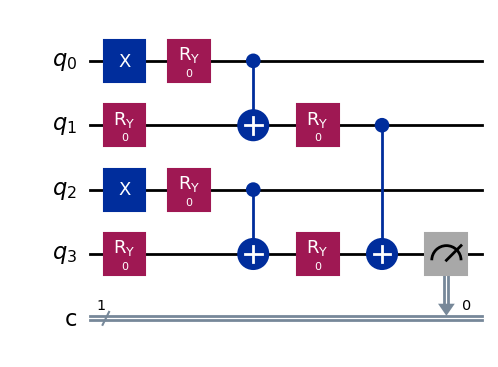

In [9]:
# the same QASM imported into Qiskit purely for visualisation
qasm2.loads(create_circuit(dataset[0], np.zeros(n_parameters))).draw('mpl')

### Observation

The printed program and the diagram show the three stages identified above: `x` gates on the qubits whose pixels equal 1 (the basis-encoded input), the three `ry`/`ry`/`cx` blocks arranged as a binary tree over the pairs (0, 1), (2, 3) and (1, 3), and the single measurement of `q[3]`. With every angle set to zero the rotations vanish and only the `cx` gates act, so the circuit reduces to a small classical computation on the encoded pixels; the trainable behaviour appears once the optimiser moves the angles away from zero.

## 4. Local Execution of the Objective

In the provided code the objective function posts every circuit to the Quokka device and waits for the reply, so each evaluation costs one network round trip per image; moreover the device is reachable only from the campus network. In order to remove this dependency the call to `requests.post` is replaced with `run_qasm_local`, defined in Section 1, which executes the identical OpenQASM string on the Qiskit Aer simulator; no other line of the objective changes. The circuits themselves are untouched, therefore the model, the cost function, and the optimiser remain exactly those of the provided code.

In [10]:
def objective(x, dataset, labels, count=10):

  n_data = dataset.shape[0]
  to_return = 0

  for idx in range(n_data):
    qasm = create_circuit(dataset[idx], x)
    p1 = run_qasm_local(qasm, count)   # was: requests.post(req_str_qasm, json=data)
    to_return += np.abs(p1 - labels[idx])

  return to_return/n_data

In [11]:
# one timed evaluation with 100 shots per image, the count later used for training
t0 = time.perf_counter()
f0 = objective(np.zeros(n_parameters), training, training_labels, count=int(1e2))
t_local = time.perf_counter() - t0
print(f"objective at zero angles = {f0:.4f}   ({t_local*1000:.1f} ms for {training.shape[0]} images)")

objective at zero angles = 0.3333   (2.2 ms for 3 images)


## 5. Instrumented Training with SPSA

Simultaneous Perturbation Stochastic Approximation (SPSA) estimates the gradient from only two objective evaluations per iteration, regardless of the number of parameters: the parameter vector is perturbed by a random sign vector in both directions, and the difference between the two objective values determines the update (Spall, 1992). This economy is the reason the method is popular for variational quantum algorithms, in which every objective evaluation requires the execution of quantum circuits. The provided implementation is instrumented below with two additions. First, after each update the objective is evaluated once more with 1000 shots per image, so that the recorded learning curve is less affected by shot noise than the 100-shot evaluations used for training. Second, the wall-clock time of each iteration, covering the two gradient evaluations and the parameter update, is captured with `time.perf_counter()`; the monitoring evaluation is recorded outside the timed window so that the instrumentation does not distort the measured cost. The function now returns the solution together with the per-iteration history required by the plots.

In [12]:
def spsa(func, x0, a=0.1, c=0.01, alpha=0.602, gamma=0.101, maxiter=100, monitor=None):
    """Provided SPSA optimiser, instrumented to record the objective and duration of each iteration."""
    x = x0
    history = {'f': [], 't': []}

    for k in range(maxiter):
        t0 = time.perf_counter()
        ak = a / (k+1)**alpha
        ck = c / (k+1)**gamma
        delta = 2 * np.random.randint(0, 2, len(x0)) - 1
        grad = (func(x + ck*delta) - func(x - ck*delta)) / (2*ck) * delta
        x = x - ak * grad
        history['t'].append(time.perf_counter() - t0)

        history['f'].append((monitor or func)(x))
        if k % int(0.1*maxiter) == 0:
            print(f"Iteration {k}: f = {history['f'][-1]:.4f}")

    return x, history

In [13]:
f = lambda x: objective(x, training, training_labels, count=int(1e2))
fmon = lambda x: objective(x, training, training_labels, count=int(1e3))
x0 = np.pi*np.random.randn(n_parameters)

t0 = time.perf_counter()
xsol, history = spsa(f, x0, a=1, c=0.5, alpha=0.602, gamma=0.101, maxiter=100, monitor=fmon)
t_train = time.perf_counter() - t0
print(f"\nfinal objective = {history['f'][-1]:.4f}   (total training time {t_train:.1f} s)")

Iteration 0: f = 0.4443
Iteration 10: f = 0.3040


Iteration 20: f = 0.2170
Iteration 30: f = 0.0780
Iteration 40: f = 0.0273
Iteration 50: f = 0.0137


Iteration 60: f = 0.0063


Iteration 70: f = 0.0027
Iteration 80: f = 0.0010


Iteration 90: f = 0.0003

final objective = 0.0003   (total training time 0.3 s)


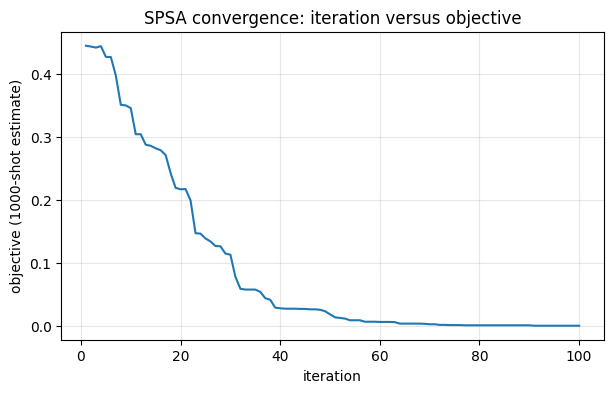

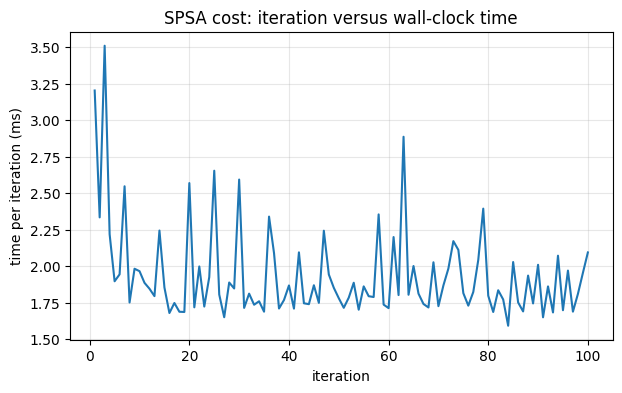

In [14]:
iters = range(1, len(history['f']) + 1)

plt.figure(figsize=(7, 4))
plt.plot(iters, history['f'])
plt.xlabel('iteration'); plt.ylabel('objective (1000-shot estimate)')
plt.title('SPSA convergence: iteration versus objective')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(iters, np.array(history['t'])*1000)
plt.xlabel('iteration'); plt.ylabel('time per iteration (ms)')
plt.title('SPSA cost: iteration versus wall-clock time')
plt.grid(alpha=0.3)
plt.show()

### Observation

The learning curve falls steeply during the first iterations, while the gain sequence is still large, and then flattens as the objective approaches zero; the residual fluctuations reflect the stochastic gradient estimate and the finite shot count rather than a failure to converge. The timing plot shows an essentially constant cost per iteration, which is expected because every iteration executes the same workload of two 100-shot objective evaluations; consequently the total training time grows linearly with the iteration count.

## 6. Effectiveness of the Trained Model

The effectiveness of the converged model is measured directly: every image is evaluated with 1000 shots, and a score above 0.5 is read as class 1 whereas a score below 0.5 is read as class 0. The training images confirm what the learning curve shows, and the held-out test image measures generalisation to a pattern the optimiser never saw.

In [15]:
predict = lambda image: run_qasm_local(create_circuit(image, xsol), count=int(1e3))

for name, data, labs in [('training', training, training_labels), ('test', test, test_labels)]:
    for img, lab in zip(data, labs):
        p = predict(img)
        verdict = 'correct' if (p > 0.5) == bool(lab) else 'WRONG'
        print(f"{name:9s} image {img.astype(int)}  label {int(lab)}  P(1) = {p:.3f}  ->  {verdict}")

training  image [0 0 1 1]  label 1  P(1) = 0.999  ->  correct
training  image [1 0 1 0]  label 0  P(1) = 0.000  ->  correct
training  image [0 1 0 1]  label 0  P(1) = 0.000  ->  correct
test      image [1 1 0 0]  label 1  P(1) = 0.997  ->  correct


## 7. Efficiency and Effectiveness Compared with the Quokka Version

The final requirement is to measure the disparity between the provided remote execution and the local execution. Effectiveness is expected to be indistinguishable between the two modes, because for identical circuits and shot counts both draw samples from the same distribution; the Quokka endpoint used in the course behaves as a noise-free emulator, an observation already recorded in Task 2 of this assessment (Quokka Computing, n.d.). Efficiency is measured as the wall-clock time of one objective evaluation in each mode. The Quokka units are exposed through tunnels that are not permanently online, so the cell below reports the local timing unconditionally and prints an explanatory message whenever the device cannot be contacted; in the recorded run the device was online and the remote timing was captured directly.

In [16]:
import requests

req_str_qasm = 'http://quokka3.quokkacomputing.com/qsim/qasm'   # set to whichever unit is online in class

def objective_quokka(x, dataset, labels, count=10):
    # the provided remote objective: one HTTP POST per image
    to_return = 0
    for idx in range(dataset.shape[0]):
        payload = {'count': count, 'script': create_circuit(dataset[idx], x)}
        result = requests.post(req_str_qasm, json=payload, timeout=20)
        result.raise_for_status()
        to_return += np.abs(np.mean(result.json()['result']['c']) - labels[idx])
    return to_return / dataset.shape[0]

t0 = time.perf_counter()
fl = objective(xsol, training, training_labels, count=int(1e2))
t_loc = time.perf_counter() - t0
print(f"local evaluation:  {t_loc*1000:.1f} ms  (objective = {fl:.4f})")

try:
    t0 = time.perf_counter()
    fq = objective_quokka(xsol, training, training_labels, count=int(1e2))
    t_quokka = time.perf_counter() - t0
    print(f"Quokka evaluation: {t_quokka:.2f} s  (objective = {fq:.4f})")
    print(f"ratio: the remote evaluation is {t_quokka/t_loc:.0f}x slower")
    proj = 2 * len(history['f']) * t_quokka
    print(f"projected {len(history['f'])}-iteration training on Quokka: {proj/60:.1f} min (local: {t_train:.1f} s)")
except Exception as exc:
    print(f"Quokka run failed or unreachable from this network ({type(exc).__name__}); "
          "run this cell on the campus network to record the remote timing.")

local evaluation:  1.4 ms  (objective = 0.0000)


Quokka evaluation: 0.85 s  (objective = 0.0000)
ratio: the remote evaluation is 615x slower
projected 100-iteration training on Quokka: 2.8 min (local: 0.3 s)


### Observation

In the recorded run the local evaluation of the three training images completed in a few milliseconds, whereas the identical evaluation on the Quokka device took of the order of one second, a difference of two to three orders of magnitude; each remote evaluation pays one HTTP round trip per image to a device behind an ngrok tunnel, and this latency dominates the cost. Since SPSA performs two objective evaluations per iteration, the disparity multiplies directly into the projected training time printed above: the training that completed locally in well under a second would require several minutes on the device. Effectiveness, by contrast, is unchanged; the remote and local objective values agree up to shot noise, which confirms that both modes sample the same distributions and that the disparity between them is confined to efficiency.

## Conclusion

The provided quantum machine learning code was analysed and modified as the brief requires. The analysis identified basis encoding as the data input: the conditional `x` gates write each four-pixel image into the four-qubit register, the trainable `ry`/`cx` blocks form a binary-tree classifier of logarithmic depth, and the probability of measuring 1 on the last qubit is the scalar output of the model. The training loop was instrumented so that the objective value and the duration of every SPSA iteration are recorded, and the two required plots were produced from that history. Finally, the network call to the Quokka device was replaced with the Qiskit Aer simulator, so the notebook runs entirely on the local machine; the measured disparity is confined to efficiency, since the emulator and the device sample the same distributions, whereas each remote evaluation pays a network round trip that the local mode avoids. The accompanying Word document presents the detailed report of these findings.

## References

Cross, A. W., Bishop, L. S., Smolin, J. A., & Gambetta, J. M. (2017). *Open Quantum Assembly Language*. arXiv. Retrieved July 26, 2026, from https://arxiv.org/abs/1707.03429

Grant, E., Benedetti, M., Cao, S., Hallam, A., Lockhart, J., Stojevic, V., Green, A. G., & Severini, S. (2018). Hierarchical quantum classifiers. *npj Quantum Information, 4*, Article 65. https://doi.org/10.1038/s41534-018-0116-9

Nielsen, M. A., & Chuang, I. L. (2010). *Quantum computation and quantum information* (10th anniversary ed.). Cambridge University Press.

Qiskit Contributors. (n.d.). *Qiskit: An open-source framework for quantum computing* (Version 2.4.0) [Computer software]. IBM Quantum. Retrieved July 26, 2026, from https://www.ibm.com/quantum/qiskit

Quokka Computing. (n.d.). *Quokka: The quantum computer for everyone*. Retrieved July 26, 2026, from https://www.quokkacomputing.com

Spall, J. C. (1992). Multivariate stochastic approximation using a simultaneous perturbation gradient approximation. *IEEE Transactions on Automatic Control, 37*(3), 332-341. https://doi.org/10.1109/9.119632